# Notebook 4 - Univariate Analysis



## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

possible_names = ["healthcare_dataset.csv", "Healthcare_dataset.csv", "Healthcare Dataset.csv", "healthcare-dataset.csv"]
data_path = None

for name in possible_names:
    if os.path.exists(name):
        data_path = name
        break

if data_path is None:
    print("Could not find the dataset automatically.")
    print("Current folder:", os.getcwd())
    print("Files in this folder:", os.listdir())
else:
    print("Found dataset at:", data_path)

df = pd.read_csv(data_path)
df.head()

Found dataset at: healthcare_dataset.csv


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


# Numerical Variables

For each numerical column, the same set of summary statistics is used:

- **Mean, Median, Mode** – three ways of describing a "typical" value.
- **Minimum, Maximum, Range** – the spread from lowest to highest value.
- **Variance, Standard Deviation** – how spread out the values are around the mean.
- **Quartiles, Percentiles** – where specific proportions of the data fall.
- **Skewness** – whether the distribution leans left, right, or is roughly symmetric.
- **Kurtosis** – whether the distribution has heavier or lighter tails than a normal distribution.

These are paired with a histogram, a KDE plot, and a box plot to visualize the shape of each distribution.

## Age

In [2]:
age = df["Age"]

age_stats = {
    "Mean": age.mean(),
    "Median": age.median(),
    "Mode": age.mode()[0],
    "Minimum": age.min(),
    "Maximum": age.max(),
    "Range": age.max() - age.min(),
    "Variance": age.var(),
    "Standard Deviation": age.std(),
    "25th Percentile": age.quantile(0.25),
    "50th Percentile": age.quantile(0.50),
    "75th Percentile": age.quantile(0.75),
    "90th Percentile": age.quantile(0.90),
    "Skewness": age.skew(),
    "Kurtosis": age.kurt()
}

pd.Series(age_stats)

Mean                   51.539459
Median                 52.000000
Mode                   38.000000
Minimum                13.000000
Maximum                89.000000
Range                  76.000000
Variance              384.256195
Standard Deviation     19.602454
25th Percentile        35.000000
50th Percentile        52.000000
75th Percentile        68.000000
90th Percentile        79.000000
Skewness               -0.005735
Kurtosis               -1.185576
dtype: float64

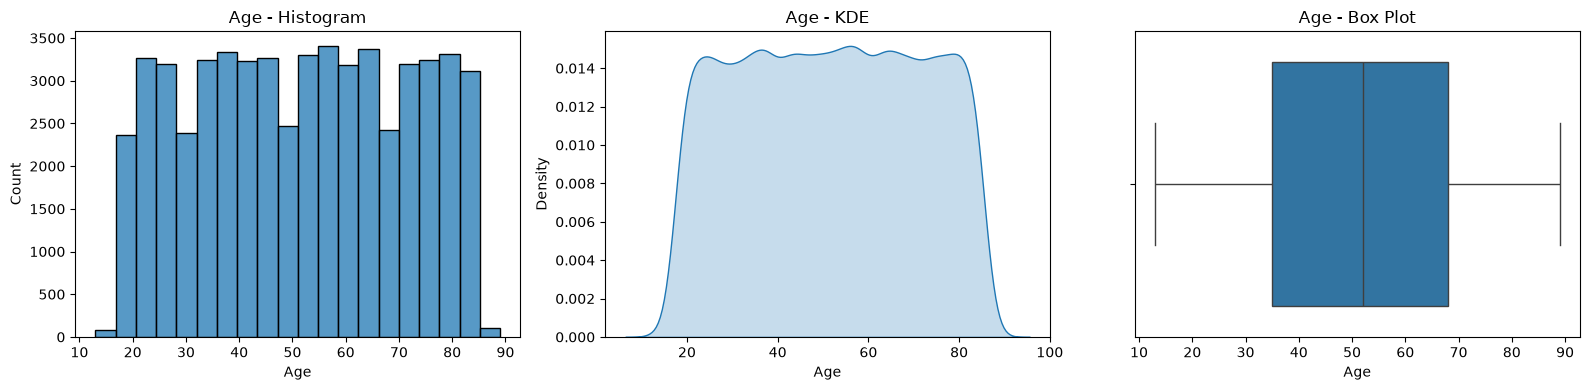

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.histplot(age, bins=20, ax=axes[0])
axes[0].set_title("Age - Histogram")
sns.kdeplot(age, fill=True, ax=axes[1])
axes[1].set_title("Age - KDE")
sns.boxplot(x=age, ax=axes[2])
axes[2].set_title("Age - Box Plot")
plt.tight_layout()
plt.show()

Age is spread fairly evenly across the adult range, roughly between the late teens and early 80s. The skewness value is close to zero, matching what the histogram shows — no strong lean toward younger or older patients — and the box plot doesn't flag any real outliers.

## Billing Amount

In [4]:
billing = df["Billing Amount"]

billing_stats = {
    "Mean": billing.mean(),
    "Median": billing.median(),
    "Mode": billing.mode()[0],
    "Minimum": billing.min(),
    "Maximum": billing.max(),
    "Range": billing.max() - billing.min(),
    "Variance": billing.var(),
    "Standard Deviation": billing.std(),
    "25th Percentile": billing.quantile(0.25),
    "50th Percentile": billing.quantile(0.50),
    "75th Percentile": billing.quantile(0.75),
    "90th Percentile": billing.quantile(0.90),
    "Skewness": billing.skew(),
    "Kurtosis": billing.kurt()
}

pd.Series(billing_stats)

Mean                  2.553932e+04
Median                2.553807e+04
Mode                 -1.316619e+03
Minimum              -2.008492e+03
Maximum               5.276428e+04
Range                 5.477277e+04
Variance              2.019654e+08
Standard Deviation    1.421145e+04
25th Percentile       1.324122e+04
50th Percentile       2.553807e+04
75th Percentile       3.782051e+04
90th Percentile       4.516299e+04
Skewness             -9.777954e-04
Kurtosis             -1.190630e+00
dtype: float64

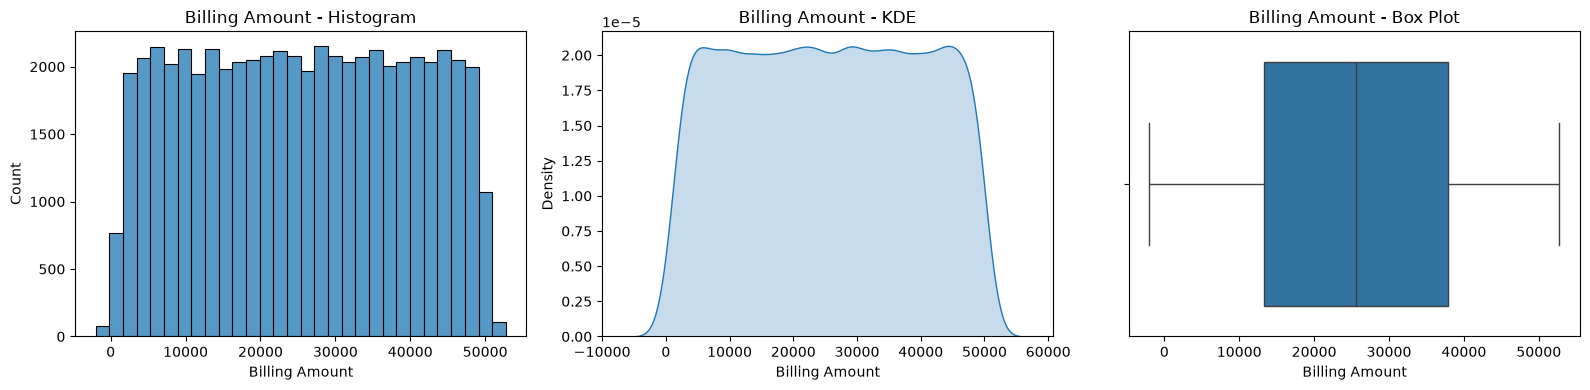

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.histplot(billing, bins=30, ax=axes[0])
axes[0].set_title("Billing Amount - Histogram")
sns.kdeplot(billing, fill=True, ax=axes[1])
axes[1].set_title("Billing Amount - KDE")
sns.boxplot(x=billing, ax=axes[2])
axes[2].set_title("Billing Amount - Box Plot")
plt.tight_layout()
plt.show()

Billing Amount is more spread out than Age, with a noticeably higher standard deviation relative to its mean. The box plot shows a few high-value cases sitting beyond the upper whisker — likely longer or more intensive admissions — which would be worth a closer look before any modeling step.

## Room Number

In [6]:
room = df["Room Number"]

room_stats = {
    "Mean": room.mean(),
    "Median": room.median(),
    "Mode": room.mode()[0],
    "Minimum": room.min(),
    "Maximum": room.max(),
    "Range": room.max() - room.min(),
    "Standard Deviation": room.std()
}

pd.Series(room_stats)

Mean                  301.134829
Median                302.000000
Mode                  393.000000
Minimum               101.000000
Maximum               500.000000
Range                 399.000000
Standard Deviation    115.243069
dtype: float64

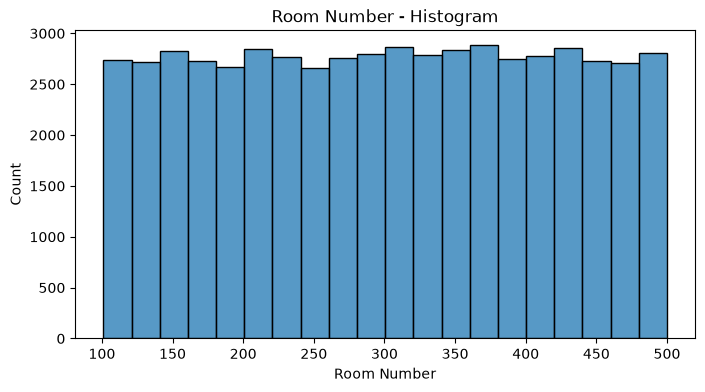

In [7]:
plt.figure(figsize=(8,4))
sns.histplot(room, bins=20)
plt.title("Room Number - Histogram")
plt.show()

Variance, quartiles, percentiles, skewness, kurtosis, KDE, and box plot are skipped here — Room Number is a room assignment, not a measurable patient attribute, so treating it as a continuous quantity would be misleading. The histogram is included only to confirm room numbers are roughly uniformly assigned, not clustered in one wing or floor.

# Categorical Variables

For each categorical column, the same checks are used: how many distinct categories exist, how often each one appears (as a count and as a percentage), and a chart to visualize the distribution. A pie chart is added only when there are few enough categories for it to stay readable — with more than 5-6 slices, a pie chart becomes cluttered and a bar or count plot works better.

## Gender

In [8]:
print("Unique categories:", df["Gender"].nunique())
print()
print(df["Gender"].value_counts())
print()
print(df["Gender"].value_counts(normalize=True) * 100)

Unique categories: 2

Gender
Male      27774
Female    27726
Name: count, dtype: int64

Gender
Male      50.043243
Female    49.956757
Name: proportion, dtype: float64


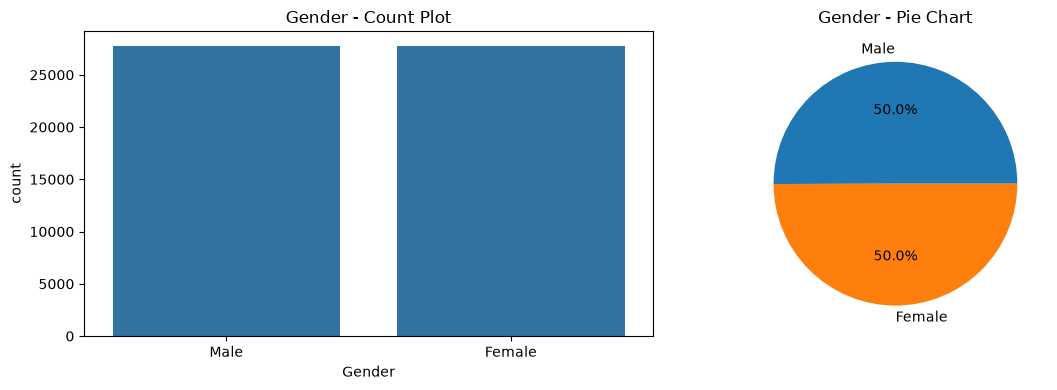

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x="Gender", data=df, ax=axes[0])
axes[0].set_title("Gender - Count Plot")
df["Gender"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1])
axes[1].set_title("Gender - Pie Chart")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

Gender is close to an even split between Male and Female, so there's no meaningful imbalance to account for in later analysis.

## Medical Condition

In [10]:
print("Unique categories:", df["Medical Condition"].nunique())
print()
print(df["Medical Condition"].value_counts())
print()
print(df["Medical Condition"].value_counts(normalize=True) * 100)

Unique categories: 6

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

Medical Condition
Arthritis       16.771171
Diabetes        16.763964
Hypertension    16.657658
Obesity         16.632432
Cancer          16.625225
Asthma          16.549550
Name: proportion, dtype: float64


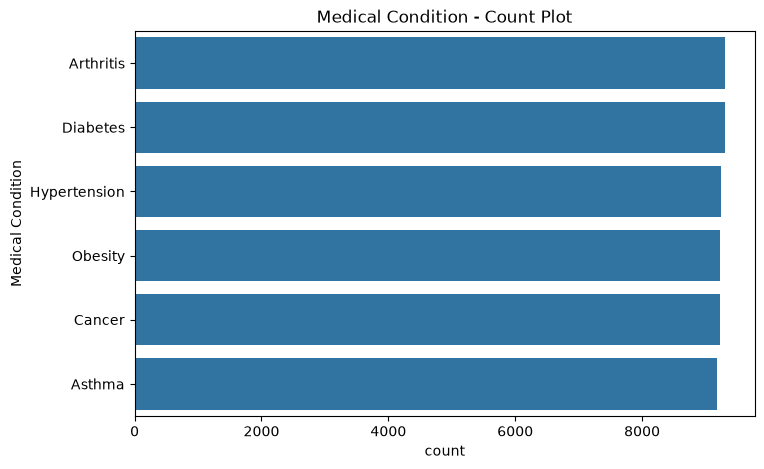

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(y="Medical Condition", data=df, order=df["Medical Condition"].value_counts().index)
plt.title("Medical Condition - Count Plot")
plt.show()

A pie chart isn't used here since there are too many conditions for the slices to stay readable. The count plot shows the different conditions occur at fairly similar rates, without any single diagnosis dominating the dataset.

## Admission Type

In [12]:
print("Unique categories:", df["Admission Type"].nunique())
print()
print(df["Admission Type"].value_counts())
print()
print(df["Admission Type"].value_counts(normalize=True) * 100)

Unique categories: 3

Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

Admission Type
Elective     33.612613
Urgent       33.470270
Emergency    32.917117
Name: proportion, dtype: float64


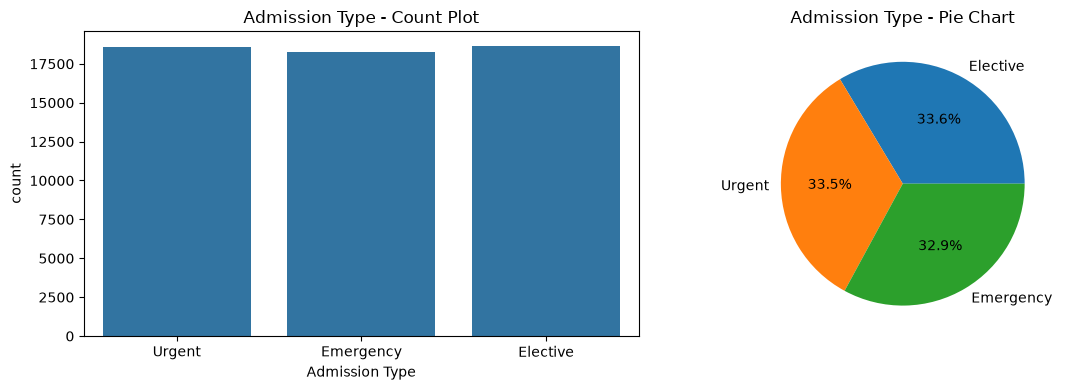

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x="Admission Type", data=df, ax=axes[0])
axes[0].set_title("Admission Type - Count Plot")
df["Admission Type"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1])
axes[1].set_title("Admission Type - Pie Chart")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

Emergency, Elective, and Urgent admissions all occur at broadly similar rates, with no single admission type standing out as unusually common or rare.

## Test Results

In [14]:
print("Unique categories:", df["Test Results"].nunique())
print()
print(df["Test Results"].value_counts())
print()
print(df["Test Results"].value_counts(normalize=True) * 100)

Unique categories: 3

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

Test Results
Abnormal        33.562162
Normal          33.363964
Inconclusive    33.073874
Name: proportion, dtype: float64


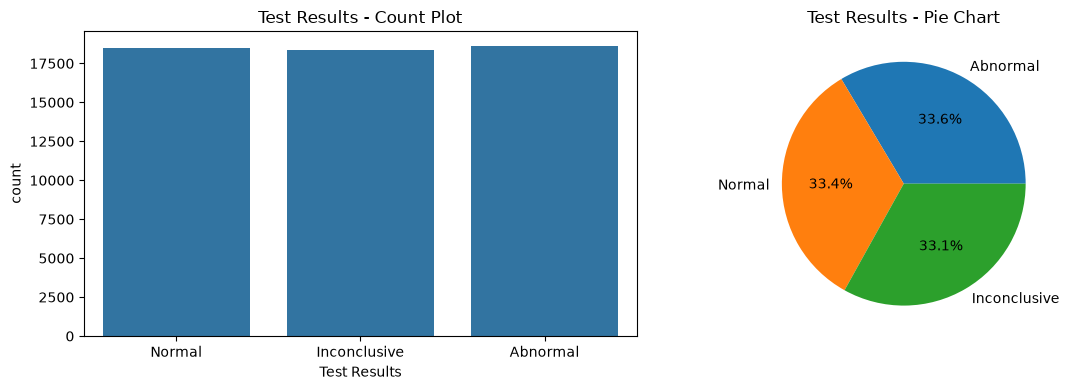

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.countplot(x="Test Results", data=df, ax=axes[0])
axes[0].set_title("Test Results - Count Plot")
df["Test Results"].value_counts().plot.pie(autopct="%1.1f%%", ax=axes[1])
axes[1].set_title("Test Results - Pie Chart")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

This is the target variable for the project. The three outcomes — Normal, Abnormal, and Inconclusive — are reasonably balanced, which is good news for later modeling since there's no dominant class that a model could exploit by simply guessing the majority outcome.

## Insurance Provider

In [16]:
print("Unique categories:", df["Insurance Provider"].nunique())
print()
print(df["Insurance Provider"].value_counts())
print()
print(df["Insurance Provider"].value_counts(normalize=True) * 100)

Unique categories: 5

Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

Insurance Provider
Cigna               20.268468
Medicare            20.097297
UnitedHealthcare    20.045045
Blue Cross          19.926126
Aetna               19.663063
Name: proportion, dtype: float64


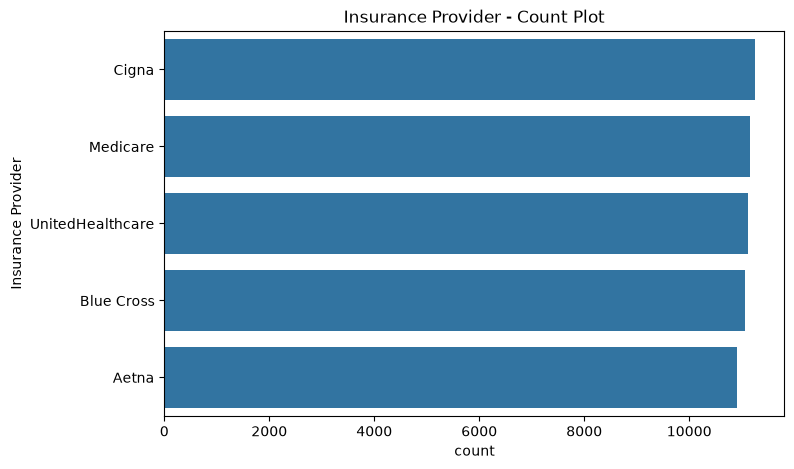

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(y="Insurance Provider", data=df, order=df["Insurance Provider"].value_counts().index)
plt.title("Insurance Provider - Count Plot")
plt.show()

As with Medical Condition, a pie chart isn't used here since it would be cluttered with too many slices. A small number of providers account for most patients, but the dataset isn't overwhelmingly dominated by any single one.